# Add a map to your website

Get started with maps

Nate Quarderer  
Elsa Culler  
2024-03-28

## Get started with map-making using open-sources tools

### Finding locations and boundaries

[Open Street Map (OSM)](https://www.openstreetmap.org/) is an
open-source, editable map of the world – a little like a wiki for
places. They also provide a service for looking up locations using text,
which we’ll be using in this activity.

### Mapping libraries

You’ll need to start by importing the following libraries:

In [7]:
# Work with vector data
import geopandas as gpd

# Save maps and plots to files
import holoviews as hv
# Create interactive maps and plots
import hvplot.pandas

# Search for locations by name - this might take a moment
import osmnx as osm

### Search for a point of interest

You can use the `pyrosm` package to download and search for spatial
vector data in your area, or anywhere around the world.

In this case, we’re looking for the location of the Haskell Indian Nations University campus in Lawrence, KS. The address in here,
`'Haskell Indian Nations University, Lawrence, KS, United States'`, does
not have to be complete or exact, but it should be specific enough to
narrow it down. We are also specifying that we want it to be tagges as a
`'amentity'` type, specifically a `'university'` You might have to try a
couple different searches with different addresses and/or tags to get
the address you want, just like if you are using a map website or app.

In [8]:
# Search for United Tribes Technical College
haskell_gdf = osm.features_from_address(
    'Haskell Indian Nations University, Lawrence, KS, United States',
    {'amenity': ['university']})
haskell_gdf

,,ways,addr:city,addr:housenumber,addr:postcode,addr:street,amenity,boundary,ele,gnis:feature_id,heritage,...,nrhp:criteria,nrhp:inscription_date,nrhp:nhl,protection_title,ref:nrhp,type,wikidata,wikipedia,nodes,geometry
element_type,osmid,,,,,,,,,,,,,,,,,,,,,
relation,2330930,"[172603550, 174576051, 174576058, 171002778, 1...",Lawrence,2300,66046,Barker Avenue,university,protected_area,268,479134,2,...,(A),"July 4, 1961",yes,protected_site,66000342,multipolygon,Q845332,en:Haskell Indian Nations University,"[[[391518501, 1834666320, 1834666332, 12070968...","POLYGON ((-95.23831 38.93552, -95.23817 38.935..."


<Axes: >

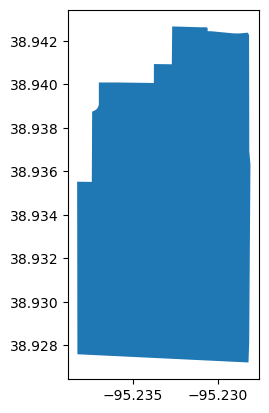

In [9]:
haskell_gdf.plot()

We have a map of the Haskell Campus!

### Create an interactive map

There are lots of different ways to create maps and plots in Python.
Here, we’re going to use a tool called `'hvplot'` and `'geoviews'` to
create an interactive map, including the online `'EsriImagery'` tile
source basemap.

In [10]:
# Plot haskell boundary
haskell_map = haskell_gdf.reset_index().hvplot(
    # Givethe map a descriptive title
    title="Haskell Indian Nations Universty, Lawrence, KS",
    # Add a basemap
    geo=True, tiles='EsriImagery',
    # Change the colors
    fill_color='white', fill_alpha=0.2,
    line_color='skyblue', line_width=5,
    # Change the image size
    frame_width=400, frame_height=400)

# Save the map as a file to put on the web
hv.save(haskell_map, 'haskell.html')

# Display the map
haskell_map

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

# Let's try another approach with OSM

In [11]:
olc_gdf = osm.geocode_to_gdf(
    'Oglala Lakota College')
olc_gdf

,geometry,bbox_north,bbox_south,bbox_east,bbox_west,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-102.24535 43.36743, -102.24525 43.3...",43.368987,43.362719,-102.237412,-102.245351,329275749,way,970931215,43.365629,-102.241208,amenity,college,30,0.344995,amenity,Oglala Lakota College,"Oglala Lakota College, BIA 2, Oglala Lakota Co..."


<Axes: >

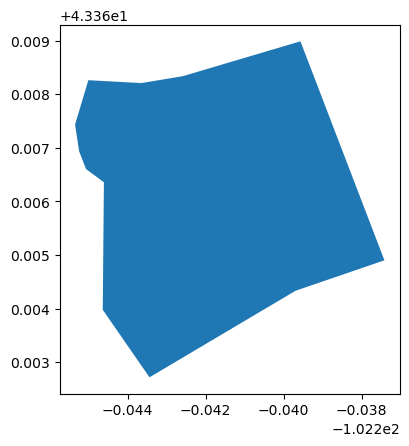

In [12]:
olc_gdf.plot()

In [16]:
# Search for OLC
olc_gdf = osm.features_from_address(
    'Oglala Lakota College, SD, United States',
    {'amenity': ['college']})
olc_gdf

,,amenity,name,geometry,nodes,wikidata
element_type,osmid,,,,,
node,2377246793,college,Oglala Lakota College,POINT (-102.24072 43.36635),NaN,NaN
way,970931215,college,Oglala Lakota College,"POLYGON ((-102.23957 43.36899, -102.23741 43.3...","[8986031620, 8986031621, 8986031622, 898603162...",Q7080082


In [17]:
# Oglala Lakota College (Kyle, SD) - Buildings
college_name = 'Oglala Lakota College'
city_name = 'Kyle'
state_name = 'South Dakota'
tags = {'building':'university', 'name':college_name, 'city':city_name, 'state':state_name}

olc_buildings_gdf = osm.features_from_place(college_name, tags)
olc_buildings_gdf

amenity                                   name  \
element_type osmid                                                        
node         2377246793  college                  Oglala Lakota College   
way          229088180       NaN               Ag and Natural Resources   
             229088181       NaN   Applied Science;Vocational Education   
             229088182       NaN                                    NaN   
             229088183       NaN                              Bookstore   
             229088184       NaN                     Education Building   
             229088185       NaN                      Historical Center   
             229088186   library        Woksape Tipi Library & Archives   
             229088187       NaN                  Multipurpose Building   
             229088188       NaN  Oglala Lakota College Central Offices   
             229088190       NaN                        Pow Wow Grounds   
             970931215   college                  Oglala Lakota College   

                                                                  geometry  \
element_type osmid                                                           
node         2377246793                        POINT (-102.24072 43.36635)   
way          229088180   POLYGON ((-102.24008 43.36692, -102.24030 43.3...   
             229088181   POLYGON ((-102.24032 43.36661, -102.24040 43.3...   
             229088182   POLYGON ((-102.24073 43.36758, -102.24089 43.3...   
             229088183   POLYGON ((-102.24177 43.36660, -102.24177 43.3...   
             229088184   POLYGON ((-102.24003 43.36599, -102.23996 43.3...   
             229088185   POLYGON ((-102.23982 43.36611, -102.23995 43.3...   
             229088186   POLYGON ((-102.24050 43.36703, -102.24068 43.3...   
             229088187   POLYGON ((-102.24236 43.36454, -102.24242 43.3...   
             229088188   POLYGON ((-102.24067 43.36563, -102.24057 43.3...   
             229088190   POLYGON ((-102.23994 43.36492, -102.23986 43.3...   
             970931215   POLYGON ((-102.23957 43.36899, -102.23741 43.3...   

                                                                     nodes  \
element_type osmid                                                           
node         2377246793                                                NaN   
way          229088180   [2377247097, 2377247078, 2377247068, 237724709...   
             229088181   [2377247073, 2377247063, 2377247055, 237724706...   
             229088182   [2377247109, 2377247107, 2377247103, 237724710...   
             229088183   [2377247072, 2377247064, 2377247062, 237724705...   
             229088184   [2377246992, 2377246984, 2377246974, 237724697...   
             229088185   [2377247003, 2377246998, 2377246988, 237724699...   
             229088186   [2377247100, 2377247091, 2377247083, 237724709...   
             229088187   [2377246853, 2377246874, 2377246872, 237724688...   
             229088188   [2377246948, 2377246956, 2377246952, 237724694...   
             229088190   [2377246900, 2377246902, 2377246909, 237724691...   
             970931215   [8986031620, 8986031621, 8986031622, 898603162...   

                           building               operator operator:type  \
element_type osmid                                                         
node         2377246793         NaN                    NaN           NaN   
way          229088180   university                    NaN           NaN   
             229088181   university                    NaN           NaN   
             229088182   university                    NaN           NaN   
             229088183   university                    NaN           NaN   
             229088184   university                    NaN           NaN   
             229088185   university                    NaN           NaN   
             229088186   university  Oglala Lakota College    university   
             229088187   uni

<Axes: >

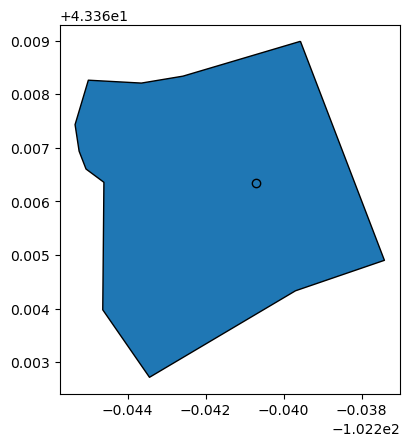

In [19]:
olc_buildings_gdf.plot(edgecolor='black')

In [20]:
olc_pw_gdf = olc_buildings_gdf[olc_buildings_gdf["name"] == "Pow Wow Grounds"]
olc_pw_gdf

,,amenity,name,geometry,nodes,building,operator,operator:type,website,wikidata
element_type,osmid,,,,,,,,,
way,229088190,NaN,Pow Wow Grounds,"POLYGON ((-102.23994 43.36492, -102.23986 43.3...","[2377246900, 2377246902, 2377246909, 237724691...",university,NaN,NaN,NaN,NaN


<Axes: >

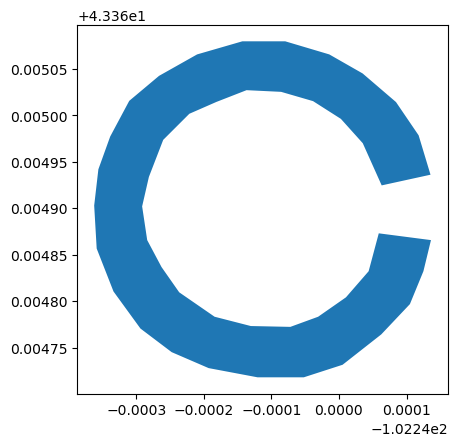

In [21]:
olc_pw_gdf.plot()